# Lab 1 — The World as Numbers

## From objects to feature vectors, images, text, signals, and high-dimensional data

This lab accompanies **Chapter 1: The World as Numbers**.

The main idea of the chapter is simple but powerful:

> Before linear algebra can describe the world, we must first translate part of the world into numbers.

In this lab, you will practice that translation in several settings:

- houses as feature vectors,
- data tables as collections of vectors,
- images as matrices of pixel values,
- sound-like signals as lists of measurements,
- text as word-count vectors,
- high-dimensional objects as points in large feature spaces.

This is not only a Python lab. It is also a thinking lab. Every time you create a vector, ask:

1. What object is being represented?
2. What does each coordinate mean?
3. What information is captured?
4. What information is lost?
5. Are the units and scales reasonable?

## 0. Lab learning goals

By the end of this lab, you should be able to:

1. Create feature vectors in Python using NumPy arrays.
2. Build a data table where each row is one object and each column is one feature.
3. Visualize two-dimensional and three-dimensional feature vectors.
4. Explain why scaling matters before comparing vectors.
5. Represent a grayscale image as a matrix of numbers.
6. Represent text as a word-count vector.
7. Explore how high-dimensional data can still contain geometric structure.
8. Use PCA, implemented with linear algebra, to compress high-dimensional data into two dimensions for visualization.

Mathematically, the main object is a vector

$$
x = \begin{bmatrix}x_1 \\ x_2 \\ \vdots \\ x_n\end{bmatrix},
$$

but the main habit is interpretation:

> A coordinate is not just a number. It is a number with meaning.

## 1. Setup

Run the following cell first. We will use only common Python tools.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plots

np.set_printoptions(precision=3, suppress=True)

print("Lab 1 setup complete.")

Lab 1 setup complete.


## 2. A single object becomes a vector

Imagine a house listing. A person may describe it using words:

> A medium-sized house, three bedrooms, not too far from the city, somewhat expensive.

A computer needs numbers. We choose four features:

1. square feet,
2. number of bedrooms,
3. distance to city center in miles,
4. price in dollars.

Then one house becomes the vector

$$
x = \begin{bmatrix}1800 \\ 3 \\ 12 \\ 550000\end{bmatrix}.
$$

The numbers alone are not enough. The coordinate dictionary gives the vector meaning.

In [2]:
feature_names = [
    "square_feet",
    "bedrooms",
    "distance_to_city_miles",
    "price_dollars"
]

house = np.array([1800, 3, 12, 550000])

for name, value in zip(feature_names, house):
    print(f"{name:25s}: {value}")

square_feet              : 1800
bedrooms                 : 3
distance_to_city_miles   : 12
price_dollars            : 550000


### Reflection

The vector above has four coordinates, so it lives in $\mathbb{R}^4$.

But it represents only what we decided to measure. It does **not** include neighborhood, school quality, architecture, sunlight, noise, or personal preference.

A vector is powerful, but it is never the whole object.

## 3. Many objects become a data matrix

Now suppose we have several houses. Each house is one vector. If we stack the vectors as rows, we get a data matrix.

Each row is an object. Each column is a feature.

In [3]:
houses = pd.DataFrame({
    "square_feet": [850, 1100, 1350, 1800, 2200, 2600, 3100, 3700, 4200, 5100],
    "bedrooms": [1, 2, 2, 3, 3, 4, 4, 5, 5, 6],
    "distance_to_city_miles": [2, 4, 6, 12, 15, 18, 22, 25, 35, 45],
    "age_years": [5, 12, 25, 40, 8, 18, 30, 15, 50, 7],
    "price_dollars": [520000, 610000, 580000, 550000, 720000, 760000, 820000, 930000, 880000, 1150000]
})

houses

,square_feet,bedrooms,distance_to_city_miles,age_years,price_dollars
0,850,1,2,5,520000
1,1100,2,4,12,610000
2,1350,2,6,25,580000
3,1800,3,12,40,550000
4,2200,3,15,8,720000
5,2600,4,18,18,760000
6,3100,4,22,30,820000
7,3700,5,25,15,930000
8,4200,5,35,50,880000
9,5100,6,45,7,1150000


In [4]:
X = houses.to_numpy()
print("Shape of data matrix X:", X.shape)
print("Number of houses:", X.shape[0])
print("Number of features:", X.shape[1])

Shape of data matrix X: (10, 5)
Number of houses: 10
Number of features: 5


The matrix has shape $(10,5)$.

That means:

- $10$ objects,
- $5$ features per object.

In linear algebra language, we have $10$ vectors in $\mathbb{R}^5$.

## 4. Visualizing two features at a time

Humans cannot directly see five-dimensional space. But we can look at two coordinates at a time.

Let us plot house size against price.

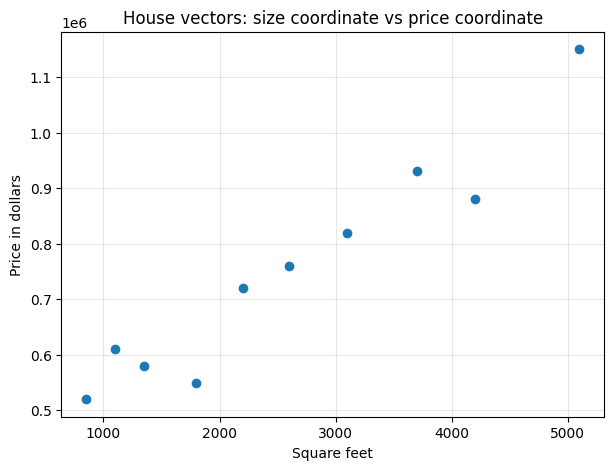

In [5]:
plt.figure(figsize=(7, 5))
plt.scatter(houses["square_feet"], houses["price_dollars"])
plt.xlabel("Square feet")
plt.ylabel("Price in dollars")
plt.title("House vectors: size coordinate vs price coordinate")
plt.grid(True, alpha=0.3)
plt.show()

### Question

What pattern do you see? Is price perfectly determined by size?

A graph like this is a two-dimensional shadow of higher-dimensional data. It uses only two coordinates and ignores the others.

## 5. A three-dimensional view

Now let us use three features: square feet, distance to city, and price.

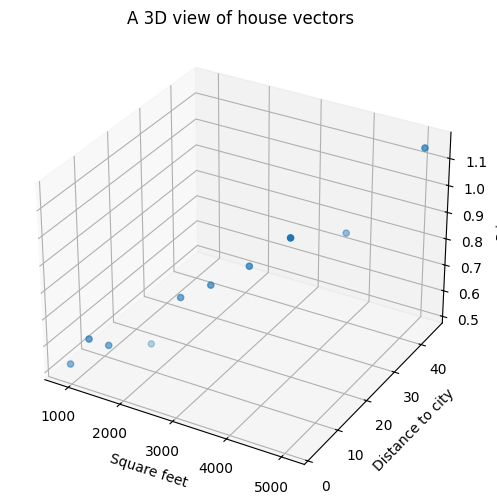

In [6]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    houses["square_feet"],
    houses["distance_to_city_miles"],
    houses["price_dollars"]
)

ax.set_xlabel("Square feet")
ax.set_ylabel("Distance to city")
ax.set_zlabel("Price")
ax.set_title("A 3D view of house vectors")
plt.show()

The same data can look different depending on which coordinates we choose to view.

This is one reason linear algebra is useful: it gives systematic tools for changing views, projecting data, and finding important directions.

## 6. Why units and scaling matter

Suppose we compare two houses using ordinary Euclidean distance.

The raw coordinates are measured in different units: square feet, bedrooms, miles, years, and dollars. The price coordinate may dominate the distance because its numbers are much larger.

In [7]:
a = houses.iloc[0].to_numpy()
b = houses.iloc[1].to_numpy()

raw_distance = np.linalg.norm(a - b)

print("House A:", a)
print("House B:", b)
print("Raw Euclidean distance:", raw_distance)
print("Difference vector:", b - a)

House A: [   850      1      2      5 520000]
House B: [  1100      2      4     12 610000]
Raw Euclidean distance: 90000.34752155127
Difference vector: [  250     1     2     7 90000]


The distance is numerically dominated by the price difference. That does not mean price is the only meaningful difference. It means our coordinate system has mixed scales.

A common first step is **standardization**:

$$
z_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j},
$$

where $\mu_j$ is the mean of feature $j$ and $\sigma_j$ is its standard deviation.

In [8]:
means = houses.mean()
stds = houses.std(ddof=0)

houses_scaled = (houses - means) / stds
houses_scaled

,square_feet,bedrooms,distance_to_city_miles,age_years,price_dollars
0,-1.306370,-1.666667,-1.249617,-1.118580,-1.228632
1,-1.119746,-1.000000,-1.097224,-0.629201,-0.752007
2,-0.933122,-1.000000,-0.944832,0.279645,-0.910882
3,-0.597198,-0.333333,-0.487655,1.328314,-1.069757
4,-0.298599,-0.333333,-0.259067,-0.908846,-0.169466
5,0.000000,0.333333,-0.030478,-0.209734,0.042367
6,0.373249,0.333333,0.274306,0.629201,0.360116
7,0.821147,1.000000,0.502895,-0.419468,0.942657
8,1.194396,1.000000,1.264856,2.027427,0.677866
9,1.866243,1.666667,2.026817,-0.978758,2.107739


In [9]:
a_scaled = houses_scaled.iloc[0].to_numpy()
b_scaled = houses_scaled.iloc[1].to_numpy()

scaled_distance = np.linalg.norm(a_scaled - b_scaled)

print("Raw distance:   ", raw_distance)
print("Scaled distance:", scaled_distance)
print("Scaled difference vector:", b_scaled - a_scaled)

Raw distance:    90000.34752155127
Scaled distance: 0.9844586992218529
Scaled difference vector: [0.187 0.667 0.152 0.489 0.477]


### Main lesson

Before comparing vectors, always ask:

> Are the coordinates measured on compatible scales?

In later chapters, this question will become central to distance, similarity, projection, PCA, clustering, and machine learning.

## 7. Student task: create your own feature vector

Choose one object from your life: a course, a city, a phone, a song, a restaurant, or a student project.

Create a vector with at least five coordinates.

Then explain what each coordinate means.

In [10]:
# TODO: Replace this example with your own object.
my_features = [
    "feature_1",
    "feature_2",
    "feature_3",
    "feature_4",
    "feature_5"
]

my_vector = np.array([0, 0, 0, 0, 0])

for name, value in zip(my_features, my_vector):
    print(f"{name:15s}: {value}")

feature_1      : 0
feature_2      : 0
feature_3      : 0
feature_4      : 0
feature_5      : 0


## 8. Images as numbers

A grayscale image is a matrix of numbers. Each number is a pixel intensity.

Usually:

- 0 means black,
- 255 means white,
- values in between are shades of gray.

Let us create a small image by hand.

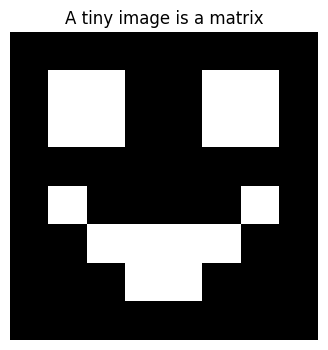

[[  0   0   0   0   0   0   0   0]
 [  0 255 255   0   0 255 255   0]
 [  0 255 255   0   0 255 255   0]
 [  0   0   0   0   0   0   0   0]
 [  0 255   0   0   0   0 255   0]
 [  0   0 255 255 255 255   0   0]
 [  0   0   0 255 255   0   0   0]
 [  0   0   0   0   0   0   0   0]]


In [11]:
pixel_art = np.array([
    [0,   0,   0,   0,   0,   0,   0,   0],
    [0, 255, 255,   0,   0, 255, 255,   0],
    [0, 255, 255,   0,   0, 255, 255,   0],
    [0,   0,   0,   0,   0,   0,   0,   0],
    [0, 255,   0,   0,   0,   0, 255,   0],
    [0,   0, 255, 255, 255, 255,   0,   0],
    [0,   0,   0, 255, 255,   0,   0,   0],
    [0,   0,   0,   0,   0,   0,   0,   0]
])

plt.figure(figsize=(4, 4))
plt.imshow(pixel_art, cmap="gray", vmin=0, vmax=255)
plt.title("A tiny image is a matrix")
plt.axis("off")
plt.show()

print(pixel_art)

This image is an $8 \times 8$ matrix. But we can also flatten it into one vector with $64$ coordinates.

That means a tiny image can be viewed as a point in $\mathbb{R}^{64}$.

In [12]:
image_vector = pixel_art.flatten()

print("Original image shape:", pixel_art.shape)
print("Flattened vector shape:", image_vector.shape)
print("First 20 coordinates:", image_vector[:20])

Original image shape: (8, 8)
Flattened vector shape: (64,)
First 20 coordinates: [  0   0   0   0   0   0   0   0   0 255 255   0   0 255 255   0   0 255
 255   0]


## 9. A more interesting image: a synthetic landscape

We can create an artificial image using mathematical functions. The result is still just a matrix of numbers.

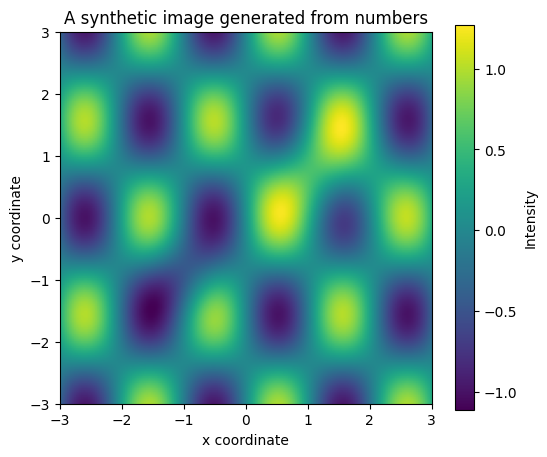

Image matrix shape: (160, 160)
As a vector, dimension: 25600


In [13]:
N = 160
x = np.linspace(-3, 3, N)
y = np.linspace(-3, 3, N)
Xgrid, Ygrid = np.meshgrid(x, y)

landscape = (
    np.sin(3 * Xgrid) * np.cos(2 * Ygrid)
    + 0.6 * np.exp(-((Xgrid - 1.2)**2 + (Ygrid + 0.7)**2))
    - 0.5 * np.exp(-((Xgrid + 1.0)**2 + (Ygrid - 1.0)**2) / 0.4)
)

plt.figure(figsize=(6, 5))
plt.imshow(landscape, cmap="viridis", extent=[-3, 3, -3, 3])
plt.colorbar(label="Intensity")
plt.title("A synthetic image generated from numbers")
plt.xlabel("x coordinate")
plt.ylabel("y coordinate")
plt.show()

print("Image matrix shape:", landscape.shape)
print("As a vector, dimension:", landscape.size)

This synthetic image has $160 \times 160 = 25{,}600$ pixel values.

So it can be treated as one vector in $\mathbb{R}^{25600}$.

This is the beginning of the idea behind image processing and computer vision.

## 10. Signals as numbers

A sound recording is also a sequence of measurements. Here we create a fake sound-like signal by combining waves.

You do not need to know Fourier analysis yet. The point here is representation: a signal is a vector of sampled values.

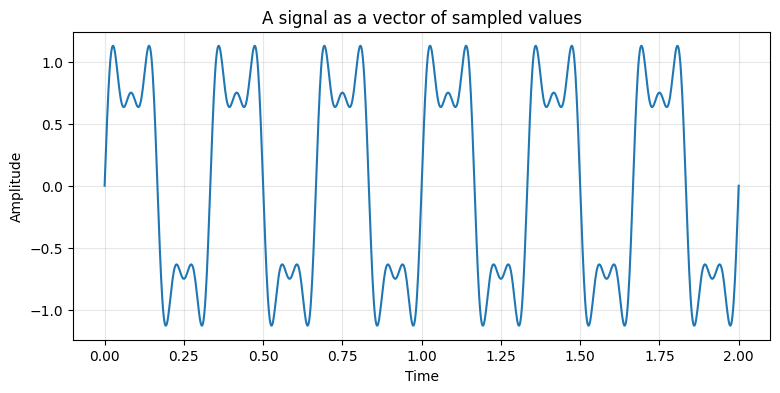

Signal vector dimension: 1000
First 10 measurements: [0.    0.141 0.28  0.414 0.54  0.658 0.765 0.859 0.94  1.007]


In [14]:
t = np.linspace(0, 2, 1000)

signal = (
    np.sin(2 * np.pi * 3 * t)
    + 0.5 * np.sin(2 * np.pi * 9 * t)
    + 0.25 * np.sin(2 * np.pi * 15 * t)
)

plt.figure(figsize=(9, 4))
plt.plot(t, signal)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("A signal as a vector of sampled values")
plt.grid(True, alpha=0.3)
plt.show()

print("Signal vector dimension:", signal.shape[0])
print("First 10 measurements:", signal[:10])

## 11. Text as numbers: a small bag-of-words model

Text does not look numerical at first. But one simple representation is to count words.

Suppose we have four short documents. We choose a vocabulary, then count how often each vocabulary word appears.

In [15]:
documents = [
    "linear algebra turns data into geometry",
    "data science uses linear models and geometry",
    "images and text can become vectors",
    "vectors and matrices are the language of linear algebra"
]

vocabulary = sorted(set(" ".join(documents).split()))

count_matrix = []
for doc in documents:
    words = doc.split()
    count_matrix.append([words.count(word) for word in vocabulary])

text_df = pd.DataFrame(count_matrix, columns=vocabulary)
text_df.index = [f"doc_{i+1}" for i in range(len(documents))]
text_df

,algebra,and,are,become,can,data,geometry,images,into,language,linear,matrices,models,of,science,text,the,turns,uses,vectors
doc_1,1,0,0,0,0,1,1,0,1,0,1,0,0,0,0,0,0,1,0,0
doc_2,0,1,0,0,0,1,1,0,0,0,1,0,1,0,1,0,0,0,1,0
doc_3,0,1,0,1,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1
doc_4,1,1,1,0,0,0,0,0,0,1,1,1,0,1,0,0,1,0,0,1


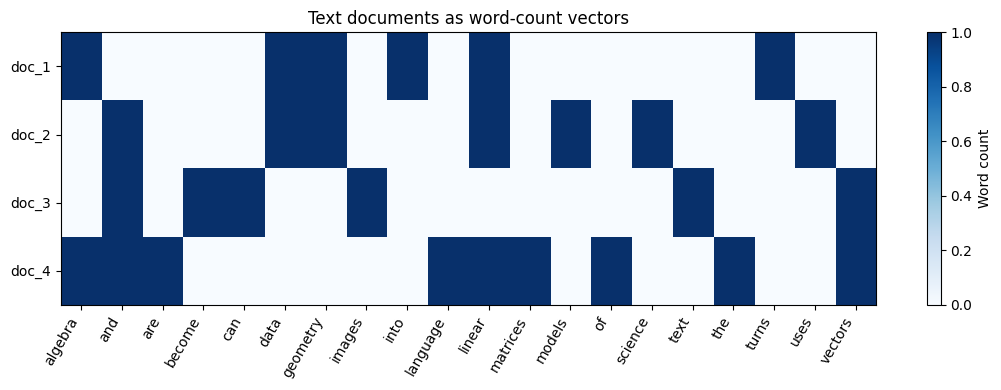

In [16]:
plt.figure(figsize=(11, 4))
plt.imshow(text_df.to_numpy(), aspect="auto", cmap="Blues")
plt.colorbar(label="Word count")
plt.xticks(range(len(vocabulary)), vocabulary, rotation=60, ha="right")
plt.yticks(range(len(documents)), text_df.index)
plt.title("Text documents as word-count vectors")
plt.tight_layout()
plt.show()

Each row is now a vector in $\mathbb{R}^d$, where $d$ is the size of the vocabulary.

This representation is simple, but it already shows a major idea in AI:

> To process language with mathematics, we need to turn text into vectors.

Modern embeddings are much more sophisticated than word counts, but they begin from the same need: represent meaning numerically.

## 12. Comparing objects by distance

Once objects become vectors, we can compare them.

One basic comparison is Euclidean distance.

In [17]:
def euclidean_distance(u, v):
    return np.linalg.norm(u - v)

for i in range(len(documents)):
    for j in range(i + 1, len(documents)):
        d = euclidean_distance(text_df.iloc[i].to_numpy(), text_df.iloc[j].to_numpy())
        print(f"Distance between doc_{i+1} and doc_{j+1}: {d:.3f}")

Distance between doc_1 and doc_2: 2.646
Distance between doc_1 and doc_3: 3.464
Distance between doc_1 and doc_4: 3.317
Distance between doc_2 and doc_3: 3.317
Distance between doc_2 and doc_4: 3.464
Distance between doc_3 and doc_4: 3.317


### Reflection

Does the smallest distance match your intuition about which two documents are most similar?

This is a good place to notice something important: the choice of representation affects the result. A word-count vector ignores word order and deeper meaning.

## 13. High-dimensional finale: artificial students in a learning app

Now we create a more interesting high-dimensional dataset.

Imagine an AI-era math learning app. Each student is represented by many features:

- algebra fluency,
- geometry fluency,
- coding fluency,
- persistence,
- speed,
- conceptual depth,
- visualization preference,
- proof comfort,
- practice frequency,
- and many other hidden measurements.

We will simulate 300 students, each represented by 60 features.

There will be three hidden learning profiles:

1. visual explorers,
2. symbolic problem-solvers,
3. computational experimenters.

The computer will only see vectors.

In [18]:
rng = np.random.default_rng(42)

n_students = 300
n_features = 60
n_groups = 3
students_per_group = n_students // n_groups

# Create three hidden centers in 60-dimensional space.
centers = np.zeros((n_groups, n_features))

# Group 0: visual strengths in first 20 features.
centers[0, :20] = 2.5
centers[0, 20:40] = 0.5
centers[0, 40:] = 1.0

# Group 1: symbolic strengths in middle 20 features.
centers[1, :20] = 0.5
centers[1, 20:40] = 2.5
centers[1, 40:] = 1.0

# Group 2: computational strengths in last 20 features.
centers[2, :20] = 1.0
centers[2, 20:40] = 0.5
centers[2, 40:] = 2.5

student_vectors = []
labels = []

for g in range(n_groups):
    block = centers[g] + rng.normal(0, 0.9, size=(students_per_group, n_features))
    student_vectors.append(block)
    labels.extend([g] * students_per_group)

S = np.vstack(student_vectors)
labels = np.array(labels)

print("Student data shape:", S.shape)
print("Each student is a vector in R^", S.shape[1], sep="")

Student data shape: (300, 60)
Each student is a vector in R^60


Let us inspect the first student vector. It has 60 coordinates, so printing all of it is already less intuitive than plotting two or three features.

In [19]:
print(S[0])

[ 2.774  1.564  3.175  3.347  0.744  1.328  2.615  2.215  2.485  1.732
  3.291  3.2    2.559  3.515  2.921  1.727  2.832  1.637  3.291  2.455
  0.334 -0.113  1.6    0.361  0.115  0.183  0.979  0.829  0.871  0.888
  2.427  0.134  0.039 -0.232  1.054  1.516  0.397 -0.256 -0.242  1.086
  1.669  1.489  0.401  1.209  1.105  1.197  1.784  1.201  1.611  1.061
  1.26   1.568 -0.311  0.712  0.577  0.425  0.752  2.345  0.221  1.871]


## 14. Heatmap view of high-dimensional vectors

A heatmap lets us see a data matrix as an image.

Rows are students. Columns are features.

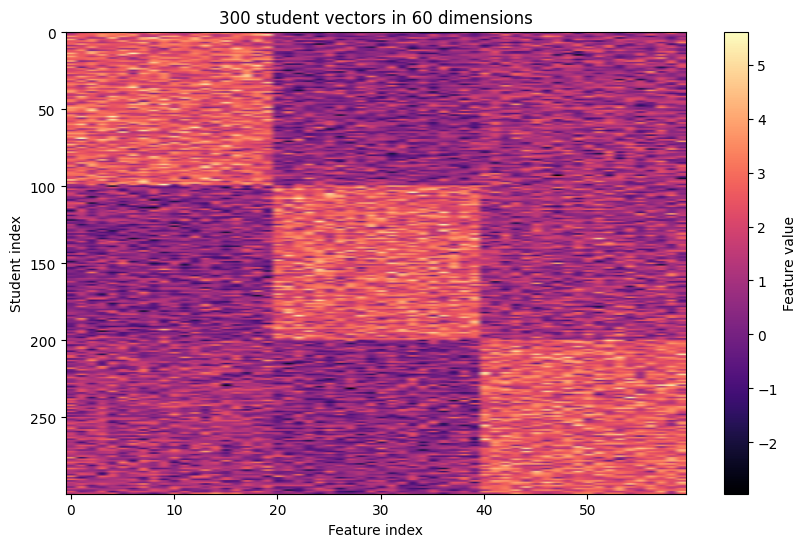

In [20]:
plt.figure(figsize=(10, 6))
plt.imshow(S, aspect="auto", cmap="magma")
plt.colorbar(label="Feature value")
plt.xlabel("Feature index")
plt.ylabel("Student index")
plt.title("300 student vectors in 60 dimensions")
plt.show()

The heatmap reveals structure that is hard to see from raw numbers. The three large horizontal regions correspond to the three hidden learning profiles.

This is a useful lesson:

> A data matrix can itself be viewed as an image.

## 15. Reducing dimension with PCA using linear algebra

We now want to visualize the 60-dimensional student vectors in two dimensions.

A common method is **principal component analysis** (PCA). Later in the book, PCA will become a major topic. Here we use it as a preview.

The idea is:

1. Center the data by subtracting the mean vector.
2. Find important directions of variation.
3. Project the data onto the first two important directions.

We can do this using the singular value decomposition.

In [21]:
# Step 1: center the data
S_centered = S - S.mean(axis=0)

# Step 2: singular value decomposition
U, singular_values, Vt = np.linalg.svd(S_centered, full_matrices=False)

# Step 3: project onto the first two principal directions
S_2d = S_centered @ Vt[:2].T

print("Original shape:", S.shape)
print("Projected shape:", S_2d.shape)
print("First five singular values:", singular_values[:5])

Original shape: (300, 60)
Projected shape: (300, 2)
First five singular values: [93.892 68.036 22.019 21.641 21.204]


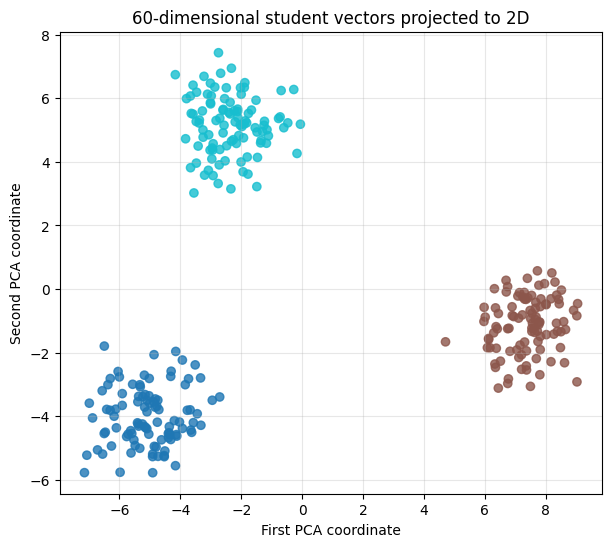

In [22]:
plt.figure(figsize=(7, 6))
plt.scatter(S_2d[:, 0], S_2d[:, 1], c=labels, cmap="tab10", alpha=0.8)
plt.xlabel("First PCA coordinate")
plt.ylabel("Second PCA coordinate")
plt.title("60-dimensional student vectors projected to 2D")
plt.grid(True, alpha=0.3)
plt.show()

Even though the original data lived in $\mathbb{R}^{60}$, the two-dimensional projection reveals the hidden groups.

This is one of the big promises of linear algebra:

> High-dimensional data may have low-dimensional structure.

## 16. The strange geometry of high dimensions

High-dimensional spaces can behave differently from two-dimensional or three-dimensional space.

Let us compare random points in different dimensions.

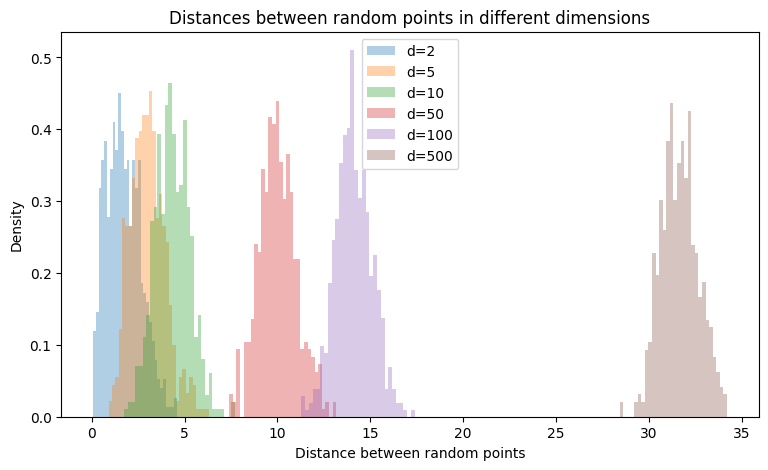

In [23]:
def random_distance_summary(d, n_points=500, seed=0):
    rng = np.random.default_rng(seed)
    A = rng.normal(size=(n_points, d))
    B = rng.normal(size=(n_points, d))
    distances = np.linalg.norm(A - B, axis=1)
    return distances

dimensions = [2, 5, 10, 50, 100, 500]

plt.figure(figsize=(9, 5))
for d in dimensions:
    distances = random_distance_summary(d)
    plt.hist(distances, bins=30, alpha=0.35, density=True, label=f"d={d}")

plt.xlabel("Distance between random points")
plt.ylabel("Density")
plt.title("Distances between random points in different dimensions")
plt.legend()
plt.show()

As dimension increases, distances tend to become larger and more concentrated.

This matters in data science and machine learning because many methods depend on distance or similarity.

High dimension is powerful, but it must be handled carefully.

## 17. Student challenge: change the high-dimensional simulation

Try changing the simulation above.

Suggested experiments:

1. Change `n_features` from 60 to 10, 100, or 500.
2. Increase the noise level from `0.9` to `1.5` or `2.5`.
3. Change the three group centers so that the groups overlap more.
4. Re-run PCA and see whether the 2D plot still separates the groups.
5. Write a short paragraph explaining what changed.

In [24]:
# TODO: Copy the simulation code here and modify it.
# What happens when the dimension increases?
# What happens when the noise increases?
# What happens when the hidden groups become closer together?

## 18. Mini-project: design a numerical representation

Choose one of the following domains:

1. songs,
2. restaurants,
3. courses,
4. cities,
5. movies,
6. student learning behavior,
7. medical records,
8. research papers,
9. images,
10. sports players.

Your task:

1. Define at least 10 features.
2. Create a small dataset with at least 8 objects.
3. Store the dataset in a pandas DataFrame.
4. Make at least two plots.
5. Standardize the features.
6. Compute distances between some objects.
7. Explain what your representation captures and what it loses.

In [ ]:
# TODO: Mini-project starter template

objects = ["object_1", "object_2", "object_3", "object_4"]

# Replace these with meaningful feature names.
features = ["feature_A", "feature_B", "feature_C"]

# Replace this with your own data.
data = np.array([
    [1.0, 2.0, 3.0],
    [2.0, 1.0, 4.0],
    [3.0, 3.0, 2.0],
    [4.0, 2.0, 1.0]
])

project_df = pd.DataFrame(data, index=objects, columns=features)
project_df

,feature_A,feature_B,feature_C
object_1,1.0,2.0,3.0
object_2,2.0,1.0,4.0
object_3,3.0,3.0,2.0
object_4,4.0,2.0,1.0


## 19. AI companion activities

Use an AI assistant as a learning partner, not as a replacement for your own thinking.

Try these prompts:

1. *I am representing restaurants as vectors. Here are my features: ... What information might this representation miss?*
2. *Explain why scaling matters before computing distances between feature vectors. Give me a simple example.*
3. *I made a word-count representation of documents. What are the limitations of this representation?*
4. *Explain PCA intuitively as a way to find a good two-dimensional shadow of high-dimensional data.*
5. *Give me three examples where an object can be represented in more than one reasonable vector language.*

After using AI, write down one thing you understood better and one thing you still want to ask.

## 20. Lab summary

In this lab, we practiced the first move of linear algebra:

> Turn objects into numbers.

We saw that:

- a house can be a vector of features,
- a dataset can be a matrix,
- an image can be a matrix or a long vector,
- a signal can be a vector of measurements,
- text can be a word-count vector,
- high-dimensional data can still have visible structure after projection.

The most important lesson is not a formula. It is a habit:

> Whenever you see a vector, ask what its coordinates mean.

This habit will guide the rest of the book.